# Task 2: Multi-Modal Cardiac Image Fusion

This notebook combines the corresponding CT and MRI slices for Patient 0001. CT receives the larger fusion weight to preserve anatomical edges, while MRI contributes soft-tissue contrast.

In [3]:
import os
print(os.getcwd())

e:\abseruni\CV-2026\Labs\02\Task_2_Cardiac_Fusion


In [5]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

__file__ = "modal_fusion.py"

DATA_DIR = Path.cwd() / "data"
OUTPUT_DIR = Path.cwd() / "output"

CT_PATH = DATA_DIR / "Patient_0001_CT" / "slice_001.png"
MRI_PATH = DATA_DIR / "Patient_0001_MRI" / "slice_001.png"

if not CT_PATH.exists() or not MRI_PATH.exists():
    raise FileNotFoundError(f"Expected CT and MRI slices at {CT_PATH} and {MRI_PATH}")
ct = cv2.imread(str(CT_PATH), cv2.IMREAD_GRAYSCALE)
mri = cv2.imread(str(MRI_PATH), cv2.IMREAD_GRAYSCALE)
if ct is None or mri is None:
    raise ValueError("OpenCV could not decode one or both input images")
if ct.shape != mri.shape:
    raise ValueError(f"CT and MRI slices must have the same dimensions; got {ct.shape} and {mri.shape}")

print(f"CT shape: {ct.shape}, MRI shape: {mri.shape}")

CT shape: (256, 256), MRI shape: (256, 256)


In [6]:
# Equalize each modality independently before blending.
ct_equalized = cv2.equalizeHist(ct)
mri_equalized = cv2.equalizeHist(mri)

# Color mapping makes the modalities visually distinguishable before fusion.
ct_color = cv2.applyColorMap(ct_equalized, cv2.COLORMAP_BONE)
mri_color = cv2.applyColorMap(mri_equalized, cv2.COLORMAP_JET)

# CT is weighted more heavily to retain sharp anatomical boundaries.
ct_weight = 0.70
mri_weight = 0.30
fused_color = cv2.addWeighted(ct_color, ct_weight, mri_color, mri_weight, 0.0)
fused_gray = cv2.addWeighted(ct_equalized, ct_weight, mri_equalized, mri_weight, 0.0)

print(f"Fusion weights: CT={ct_weight:.2f}, MRI={mri_weight:.2f}")

Fusion weights: CT=0.70, MRI=0.30


In [7]:
# Log and power-law transforms improve visibility without changing the fusion inputs.
def normalize_to_uint8(image: np.ndarray) -> np.ndarray:
    image_float = image.astype(np.float32)
    minimum = float(image_float.min())
    maximum = float(image_float.max())
    if maximum <= minimum:
        return np.zeros_like(image, dtype=np.uint8)
    normalized = (image_float - minimum) / (maximum - minimum)
    return np.uint8(np.round(normalized * 255.0))

fused_normalized = fused_gray.astype(np.float32) / 255.0
log_fused = normalize_to_uint8(np.log1p(fused_normalized) / np.log(2.0))
gamma = 0.85
power_fused = normalize_to_uint8(np.power(fused_normalized, gamma))

cv2.imwrite(str(OUTPUT_DIR / "fused_color.png"), fused_color)
cv2.imwrite(str(OUTPUT_DIR / "fused_log.png"), log_fused)
cv2.imwrite(str(OUTPUT_DIR / "fused_power.png"), power_fused)
print(f"Saved fusion outputs to {OUTPUT_DIR.resolve()}")

Saved fusion outputs to E:\abseruni\CV-2026\Labs\02\Task_2_Cardiac_Fusion\output


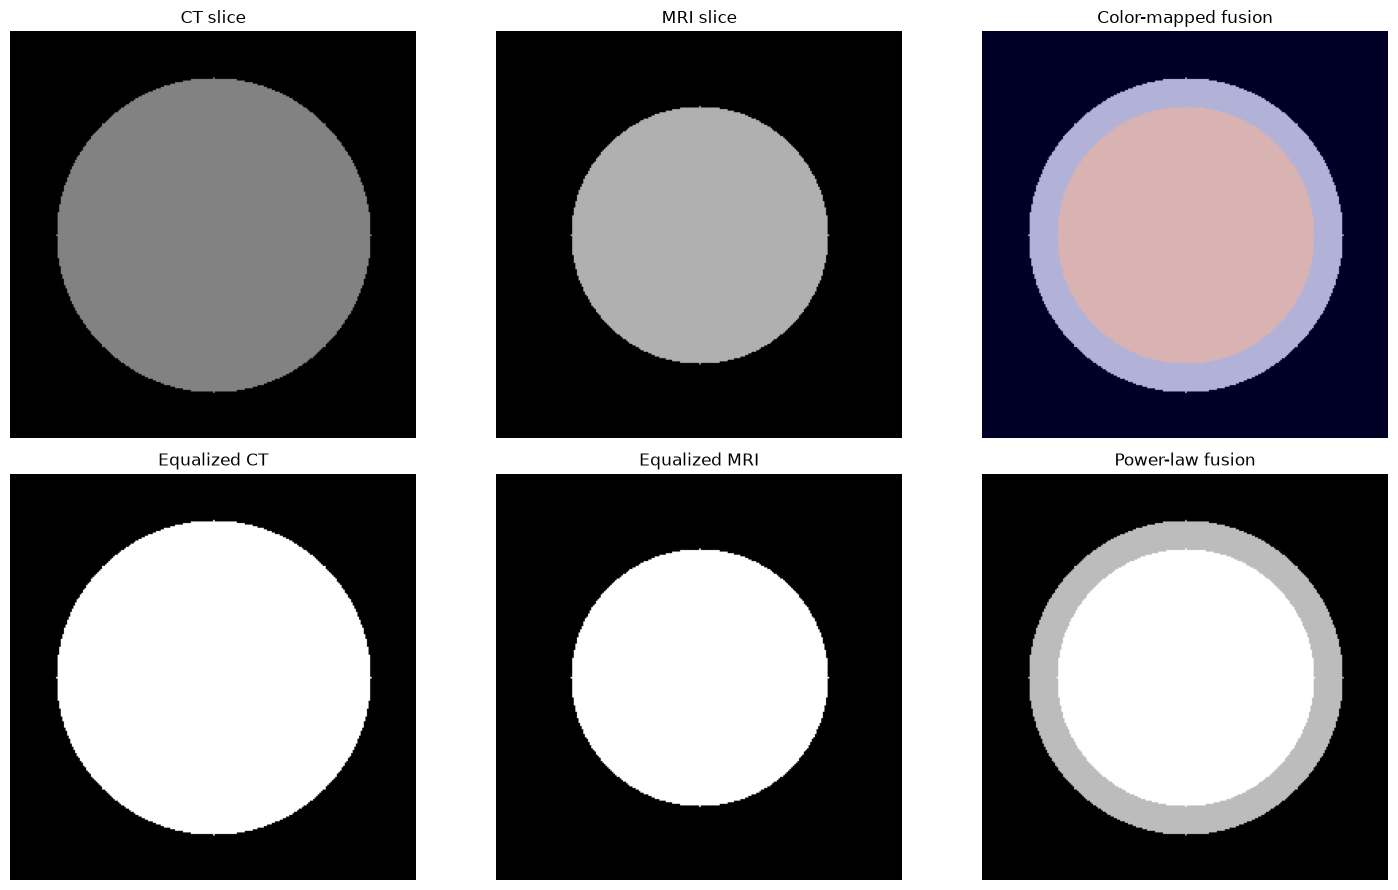

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
images = [
    (ct, "CT slice", "gray"),
    (mri, "MRI slice", "gray"),
    (fused_color, "Color-mapped fusion", None),
    (ct_equalized, "Equalized CT", "gray"),
    (mri_equalized, "Equalized MRI", "gray"),
    (power_fused, "Power-law fusion", "gray"),
]
for axis, (image, title, cmap) in zip(axes.flat, images):
    if cmap is None:
        axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        axis.imshow(image, cmap=cmap, vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")
fig.tight_layout()
plt.show()

## Comparative analysis

The CT and MRI inputs are shown independently alongside the fused result. Histogram equalization expands each modality's intensity range before fusion. The color-mapped output makes the contribution of each modality easier to distinguish, while the CT-heavy `0.70/0.30` weighting prioritizes structural edges and retains MRI's internal tissue variation. The logarithmic and power-law outputs are contrast views of the fused matrix; the raw fused matrix remains unchanged.